Group member:Jinhao Fan; Yuru Zhou; Shaoxiong Duan

The purpose of this project is to analyze and compare historical stock prices of Apple (AAPL) and Tesla (TSLA) using Python. 

This project applies data science techniques including:
- data collection
- data cleaning
- data visualization
- financial analysis
- machine learning

The analysis focuses on stock price trends, daily returns, volatility, moving averages, and simple price prediction using linear regression.

In [1]:
!pip install yfinance


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


The following libraries are imported for data analysis, visualization, and stock market data collection.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In this section, historical stock market data for Apple (AAPL) and Tesla (TSLA) are downloaded from Yahoo Finance using the yfinance library.

The dataset includes:
1.Open price
2.Close price
3.High price
4.Low price
5.Volume

In [3]:
apple = yf.download("AAPL", start="2022-01-01", end="2025-01-01")
tesla = yf.download("TSLA", start="2022-01-01", end="2025-01-01")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
apple.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103638,178.954976,173.895938,174.013357,104487900
2022-01-04,175.843216,179.013683,175.275662,178.710339,99310400
2022-01-05,171.165817,176.303140,170.891828,175.755162,94537600
2022-01-06,168.308487,171.537664,167.956213,168.993460,96904000
2022-01-07,168.474854,170.402574,167.359321,169.179402,86709100


In this section, we examine the structure and summary of the dataset, including the number of rows, columns, and data types.

In [5]:
apple.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 753 entries, 2022-01-03 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   753 non-null    float64
 1   (High, AAPL)    753 non-null    float64
 2   (Low, AAPL)     753 non-null    float64
 3   (Open, AAPL)    753 non-null    float64
 4   (Volume, AAPL)  753 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.3 KB


This section visualizes the closing price trend of Apple stock over time to observe market movements and overall trends.

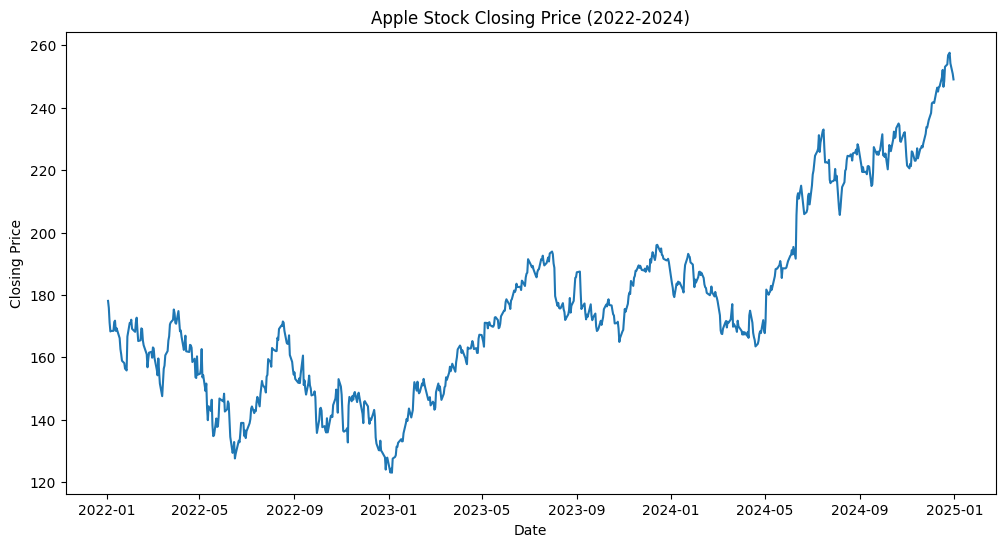

In [6]:
plt.figure(figsize=(12,6))

plt.plot(apple.index, apple[("Close", "AAPL")])

plt.title("Apple Stock Closing Price (2022-2024)")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

This section compares the historical closing prices of Apple and Tesla to observe differences in stock performance and volatility.

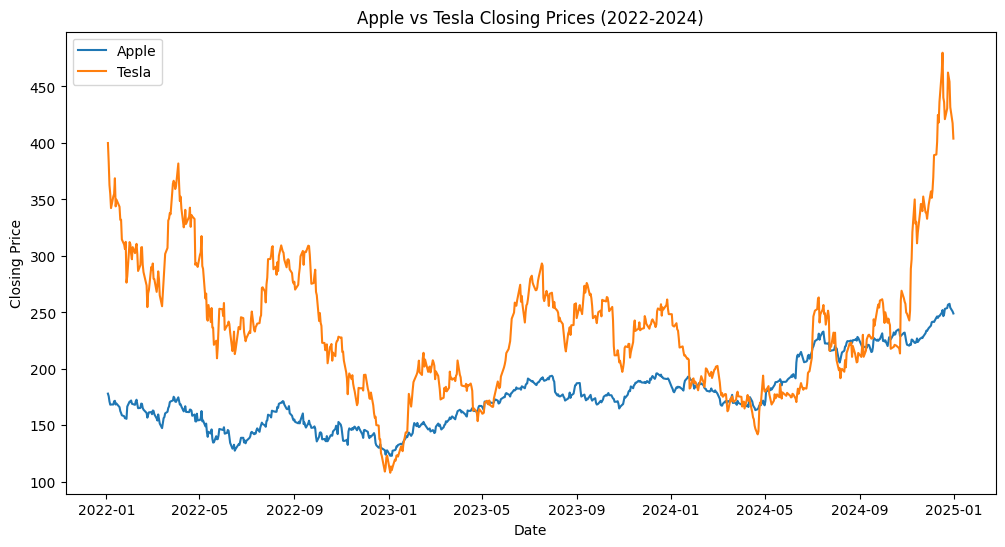

In [7]:
plt.figure(figsize=(12,6))

plt.plot(apple.index, apple[("Close", "AAPL")], label="Apple")
plt.plot(tesla.index, tesla[("Close", "TSLA")], label="Tesla")

plt.title("Apple vs Tesla Closing Prices (2022-2024)")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()

plt.show()

Daily return measures the percentage change in stock price from one day to the next. It is commonly used in financial analysis to evaluate stock performance and volatility.

In [8]:
apple["Daily Return"] = apple[("Close", "AAPL")].pct_change()

tesla["Daily Return"] = tesla[("Close", "TSLA")].pct_change()

In [9]:
apple.head()

Price,Close,High,Low,Open,Volume,Daily Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2022-01-03,178.103638,178.954976,173.895938,174.013357,104487900,NaN
2022-01-04,175.843216,179.013683,175.275662,178.710339,99310400,-0.012692
2022-01-05,171.165817,176.303140,170.891828,175.755162,94537600,-0.026600
2022-01-06,168.308487,171.537664,167.956213,168.993460,96904000,-0.016693
2022-01-07,168.474854,170.402574,167.359321,169.179402,86709100,0.000988


This section visualizes the distribution of Apple daily returns to better understand stock volatility and return behavior.

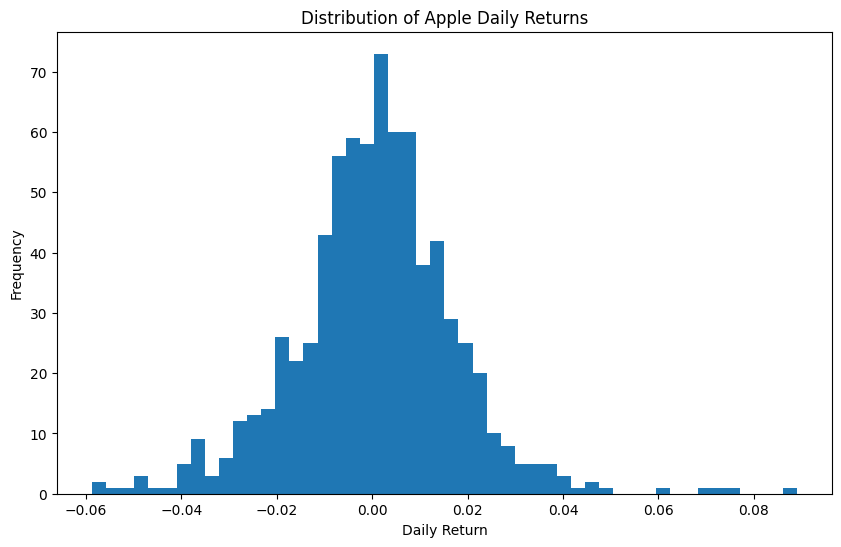

In [10]:
plt.figure(figsize=(10,6))

plt.hist(apple["Daily Return"].dropna(), bins=50)

plt.title("Distribution of Apple Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

Volatility measures the degree of variation in stock returns over time. In finance, higher volatility usually indicates higher investment risk.

In [11]:
apple_volatility = apple["Daily Return"].std()

tesla_volatility = tesla["Daily Return"].std()

print("Apple Volatility:", apple_volatility)
print("Tesla Volatility:", tesla_volatility)

Apple Volatility: 0.01706730574656781
Tesla Volatility: 0.03861776043609606


Moving averages are commonly used in financial analysis to smooth short-term fluctuations and identify long-term market trends.

In [12]:
apple["MA_30"] = apple[("Close", "AAPL")].rolling(window=30).mean()

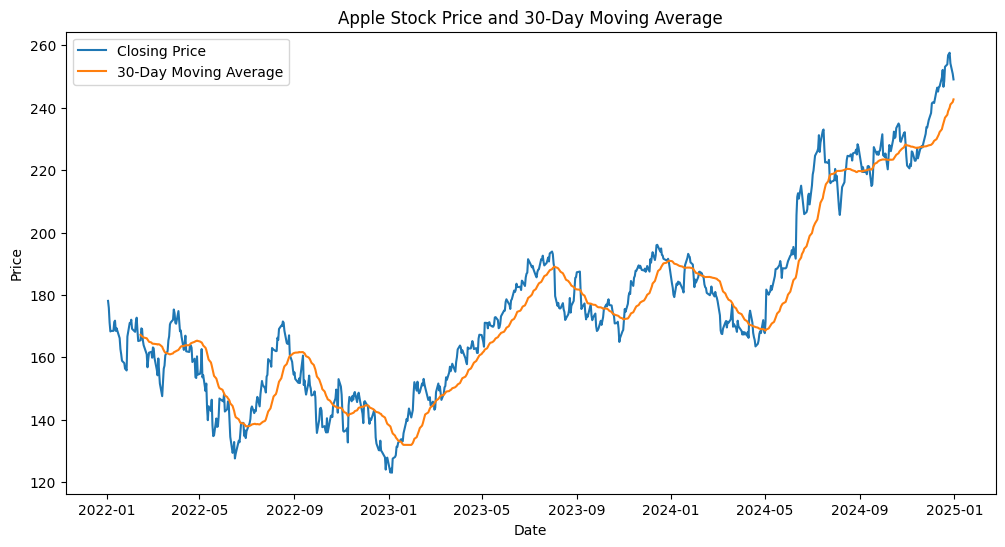

In [13]:
plt.figure(figsize=(12,6))

plt.plot(apple.index, apple[("Close", "AAPL")], label="Closing Price")

plt.plot(apple.index, apple["MA_30"], label="30-Day Moving Average")

plt.title("Apple Stock Price and 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

Linear regression is used to model the relationship between time and Apple stock prices. The model helps identify overall price trends and provides a simple prediction of stock movement.

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
apple = apple.reset_index()

The dataset is prepared by converting dates into numerical values so that the regression model can analyze the relationship between time and stock prices.

In [16]:
apple["Day"] = np.arange(len(apple))

In [17]:
X = apple[["Day"]]

y = apple[("Close", "AAPL")]

The linear regression model is trained using the relationship between time and Apple stock closing prices.

In [18]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


The trained regression model is used to generate predicted stock prices based on the historical trend of Apple stock data.

In [19]:
apple["Predicted Price"] = model.predict(X)

This visualization compares the actual Apple stock prices with the prices predicted by the linear regression model.

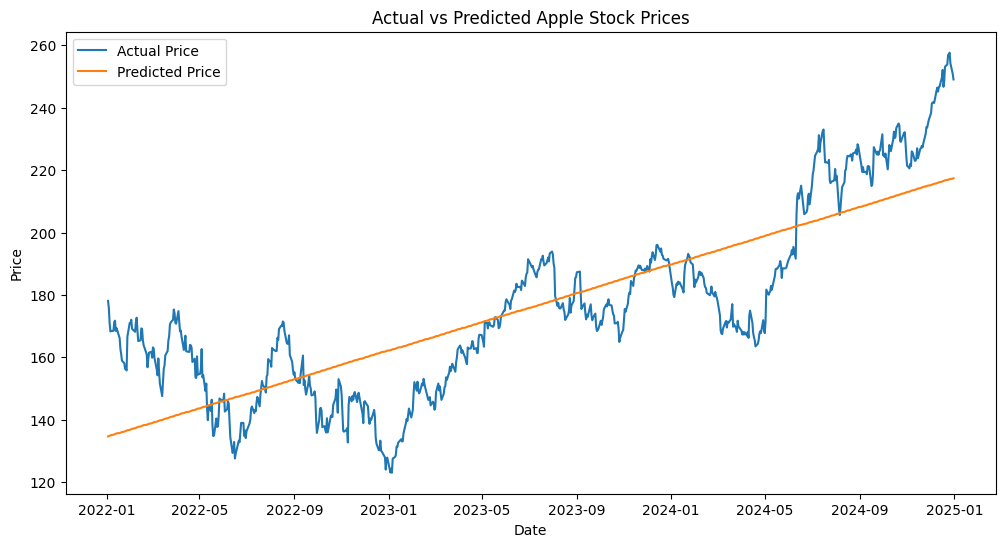

In [20]:
plt.figure(figsize=(12,6))

plt.plot(apple["Date"], apple[("Close", "AAPL")], label="Actual Price")

plt.plot(apple["Date"], apple["Predicted Price"], label="Predicted Price")

plt.title("Actual vs Predicted Apple Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

The R² score is used to evaluate how well the regression model explains variations in Apple stock prices.

In [21]:
r_squared = model.score(X, y)

print("R-squared:", r_squared)

R-squared: 0.6588108504757286


Conclusion

This project analyzed historical stock price data for Apple (AAPL) and Tesla (TSLA) using Python and data science techniques.

The analysis showed that:

- Apple demonstrated relatively stable long-term growth.
- Tesla exhibited significantly higher volatility and investment risk.
- Daily return distributions were centered around zero with occasional extreme fluctuations.
- Moving averages helped identify long-term stock price trends.
- The linear regression model successfully captured the general upward trend in Apple stock prices, although it could not fully explain short-term market fluctuations.

Overall, this project demonstrated the application of data collection, visualization, financial analysis, and machine learning techniques in stock market analysis.

Reference

1. Yahoo Finance: https://finance.yahoo.com/

2. yfinance Python Library:
https://pypi.org/project/yfinance/

3. Scikit-learn Documentation:
https://scikit-learn.org/

4. Matplotlib Documentation:
https://matplotlib.org/

5. Pandas Documentation:
https://pandas.pydata.org/